In [ ]:
!pip install audiomentations  #added by David

In [ ]:
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torchaudio

import os
import sys

from transformers import EarlyStoppingCallback  # added by David

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Select the Runtime > "Change runtime type" menu to enable a GPU accelerator, ')
  print('and then re-execute this cell.')
else:
  print(gpu_info)

Thu Apr 30 17:06:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             28W /   70W |   13055MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%capture
!pip install transformers
!pip install datasets

In [ ]:
%%capture
!sudo apt-get install git-lfs


In [ ]:
%%capture
!git lfs install
!--system
!--skip-repo

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from datasets import load_dataset

data_files = {
    'train': '/content/drive/My Drive/type3/data/train_dm.csv',
    'valid': '/content/drive/My Drive/type3/data/valid_dm.csv'
    }

dataset = load_dataset("csv", data_files=data_files, delimiter="\t", )
train_data = dataset['train']
valid_data = dataset['valid']

print(train_data)
print(valid_data)

Dataset({
    features: ['file', 'label', 'path'],
    num_rows: 227
})
Dataset({
    features: ['file', 'label', 'path'],
    num_rows: 48
})


In [ ]:
repo_name = "dementia-baseline-model"

In [ ]:
input_col = 'path'
output_col = 'label'
audio_len = 32

In [ ]:
label_list = train_data.unique(output_col)
label_list.sort()
num_classes = len(label_list)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_list}")

Number of classes: 2
Classes: ['dementia', 'nodementia']


In [ ]:
from random import randint

def random_subsample(wav: np.ndarray, max_length: float, sample_rate: int = 16000):
    """Randomly sample chunks of `max_length` seconds from the input audio"""
    sample_length = int(round(sample_rate * max_length))
    if len(wav) <= sample_length:
        return wav
    random_offset = randint(0, len(wav) - sample_length - 1)
    return wav[random_offset : random_offset + sample_length]

In [ ]:
from transformers import AutoConfig, Wav2Vec2Processor, Wav2Vec2FeatureExtractor

In [ ]:
model_name = "facebook/wav2vec2-xls-r-300m"
pooling_mode = "mean"

In [ ]:
config = AutoConfig.from_pretrained(
    model_name,
    num_labels=num_classes,
    label2id={label: i for i, label in enumerate(label_list)},
    id2label={i: label for i, label in enumerate(label_list)},
    finetuning_task="wav2vec2_clf",
    )

setattr(config, "pooling_mode", pooling_mode)

In [ ]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name,)
target_sampling_rate = feature_extractor.sampling_rate
print(f"The target sampling rate: {target_sampling_rate}")

The target sampling rate: 16000


In [ ]:
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
# This pipeline applies these effects with a 50% probability (p=0.5) - David
augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.005, p=0.50),    #changed max_amplitude from 0.015 to 0.005 to lower intensity  -David
    TimeStretch(min_rate=0.8, max_rate=1.1, p=0.50),      #changed max_rate to 1.1 from 1.25 to lower intensity -David
    PitchShift(min_semitones=-4, max_semitones=4, p=0.50)
])

In [ ]:
def speech_to_array_train(path):
    speech, sr = torchaudio.load(path)
    transform = torchaudio.transforms.Resample(sr, 16000)
    speech = transform(speech)[0].numpy().squeeze()

    # NEW: Apply the synthetic augmentations  - David
    speech = augmenter(samples=speech, sample_rate=16000)

    return random_subsample(speech, max_length=audio_len)

def speech_to_array_valid(path):
    speech, sr = torchaudio.load(path)
    transform = torchaudio.transforms.Resample(sr, 16000)
    speech = transform(speech)[0].numpy().squeeze()
    return random_subsample(speech, max_length=audio_len)

def label_to_id(label, label_list):
    if len(label_list) > 0:
        return label_list.index(label) if label in label_list else -1
    return label

# Train preprocessor uses the augmented array - David
def preprocess_fn_train(examples):
    speech_list = [speech_to_array_train(path) for path in examples[input_col]]
    target_list = [label_to_id(label, label_list) for label in examples[output_col]]
    result = feature_extractor(speech_list, sampling_rate=target_sampling_rate)
    result['labels'] = list(target_list)
    return result

# Valid preprocessor uses the clean array  - David
def preprocess_fn_valid(examples):
    speech_list = [speech_to_array_valid(path) for path in examples[input_col]]
    target_list = [label_to_id(label, label_list) for label in examples[output_col]]
    result = feature_extractor(speech_list, sampling_rate=target_sampling_rate)
    result['labels'] = list(target_list)
    return result


In [ ]:
train_data = train_data.map(preprocess_fn_train, batch_size=8, batched=True, num_proc=4)
valid_data = valid_data.map(preprocess_fn_valid, batch_size=8, batched=True, num_proc=4)

In [ ]:
#train_data[0].keys()

In [ ]:

#seq_len = [train_data[i]['path'] for i in range(len(train_data)) if len(train_data[i]['input_values']) < 128000]

In [ ]:
from dataclasses import dataclass
from typing import Optional, Tuple
import torch
from transformers.file_utils import ModelOutput

@dataclass
class SpeechClassifierModelOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    hidden_states: Optional[Tuple[torch.FloatTensor]] = None
    attentions: Optional[Tuple[torch.FloatTensor]] = None


In [ ]:
import torch
import torch.nn as nn
from transformers.models.wav2vec2.modeling_wav2vec2 import (Wav2Vec2PreTrainedModel, Wav2Vec2Model)

class Wav2Vec2ClassificationHead(nn.Module):
    """head for wav2vec classification task"""
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.final_dropout)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, features, **kwargs):
        x = features
        x = self.dense(x)
        x = self.dropout(x)
        x = torch.tanh(x)
        x = self.dropout(x)
        x = self.out_proj(x)
        return x

class Wav2Vec2ForSpeechClassification(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.pooling_mode = config.pooling_mode
        self.config = config

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = Wav2Vec2ClassificationHead(config)

        self.init_weights()

    def freeze_feature_extractor(self):
        self.wav2vec2.feature_extractor._freeze_parameters()

    def merge_strategy(self, hidden_states, mode="mean"):
        if mode == "mean":
            return torch.mean(hidden_states, dim=1)
        elif mode == "max":
            return torch.max(hidden_states, dim=1)[0]
        elif mode == "sum":
            return torch.sum(hidden_states, dim=1)
        else:
            raise ValueError(f"Unknown merge strategy: {mode}")

    def forward(
        self,
        input_values,
        attention_mask=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        labels=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.wav2vec2(input_values,
                            attention_mask=attention_mask,
                            output_attentions=output_attentions,
                            output_hidden_states=output_hidden_states,
                            return_dict=return_dict)

        hidden_states = outputs[0]
        hidden_states = self.merge_strategy(hidden_states, self.pooling_mode)
        logits = self.classifier(hidden_states)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SpeechClassifierModelOutput(loss=loss, logits=logits, hidden_states=outputs.hidden_states, attentions=outputs.attentions)

In [ ]:
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
import torch

import transformers
from transformers import Wav2Vec2Processor, Wav2Vec2FeatureExtractor

@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Args:
        feature_extractor (:class:`~transformers.Wav2Vec2FeatureExtractor`):
            The processor used for proccessing the data.
        padding (:obj:`bool`, :obj:`str` or :class:`~transformers.tokenization_utils_base.PaddingStrategy`, `optional`, defaults to :obj:`True`):
            Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
            among:
            * :obj:`True` or :obj:`'longest'`: Pad to the longest sequence in the batch (or no padding if only a single
              sequence if provided).
            * :obj:`'max_length'`: Pad to a maximum length specified with the argument :obj:`max_length` or to the
              maximum acceptable input length for the model if that argument is not provided.
            * :obj:`False` or :obj:`'do_not_pad'` (default): No padding (i.e., can output a batch with sequences of
              different lengths).
        max_length (:obj:`int`, `optional`):
            Maximum length of the ``input_values`` of the returned list and optionally padding length (see above).
        max_length_labels (:obj:`int`, `optional`):
            Maximum length of the ``labels`` returned list and optionally padding length (see above).
        pad_to_multiple_of (:obj:`int`, `optional`):
            If set will pad the sequence to a multiple of the provided value.
            This is especially useful to enable the use of Tensor Cores on NVIDIA hardware with compute capability >=
            7.5 (Volta).
    """
    feature_extractor: Wav2Vec2FeatureExtractor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"],} for feature in features]
        label_features = [feature["labels"] for feature in features]

        d_type = torch.long if isinstance(label_features[0], int) else torch.float

        batch = self.feature_extractor.pad( input_features,
                                    padding=self.padding,
                                    max_length=self.max_length,
                                    pad_to_multiple_of=self.pad_to_multiple_of,
                                    return_tensors="pt",
        )

        batch['labels'] = torch.tensor(label_features, dtype=d_type)

        return batch

In [ ]:
data_collator = DataCollatorCTCWithPadding(feature_extractor=feature_extractor, padding=True)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(p):                  # changed this whole block to add f1,precision, and recall - David
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    preds = np.argmax(preds, axis=1)
    labels = p.label_ids

    accuracy = accuracy_score(labels, preds)
    # Using 'weighted' accounts for potential imbalances in the dementia vs. healthy classes  -David
    f1 = f1_score(labels, preds, average='weighted')
    precision = precision_score(labels, preds, average='weighted', zero_division=0)
    recall = recall_score(labels, preds, average='weighted', zero_division=0)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
# 1. Create a physical, blank file on the Colab server  -David
open('dummy_notebook.py', 'w').close()

# 2. Point the system to this new file  -David
import sys
sys.modules['__main__'].__file__ = 'dummy_notebook.py'

In [ ]:
# Provide the missing attribute for the new library  -David
Wav2Vec2ForSpeechClassification.all_tied_weights_keys = {}

#from transformers import Wav2Vec2ForSequenceClassification   -David
model = Wav2Vec2ForSpeechClassification.from_pretrained(model_name, config=config)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSpeechClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
classifier.out_proj.bias     | MISSING    | 
classifier.out_proj.weight   | MISSING    | 
classifier.dense.weight      | MISSING    | 
classifier.dense.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model.freeze_feature_extractor()

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir= repo_name,
    group_by_length=True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    eval_strategy="steps",
    gradient_checkpointing=True,
    num_train_epochs=40,    # changed from 22 to 40 since the data is more complex, the model needs more passes to understand it - David
    logging_dir=None,
    eval_steps=34,                   # Evaluate frequently
    save_steps=34,                   # Must match eval_steps
    logging_steps=110,
    learning_rate=1e-4,
    fp16=True,
    push_to_hub=True,
)




In [ ]:
from typing import Any, Dict, Union

import torch
from packaging import version
from torch import nn

from transformers import (
    Trainer,
    is_apex_available,
)

if is_apex_available():
    from apex import amp

if version.parse(torch.__version__) >= version.parse("1.6"):
    _is_native_amp_available = True
    from torch.cuda.amp import autocast


class CTCTrainer(Trainer):
    def training_step(self, model: nn.Module, inputs: Dict[str, Union[torch.Tensor, Any]]) -> torch.Tensor:
        """
        Perform a training step on a batch of inputs.

        Subclass and override to inject custom behavior.

        Args:
            model (:obj:`nn.Module`):
                The model to train.
            inputs (:obj:`Dict[str, Union[torch.Tensor, Any]]`):
                The inputs and targets of the model.

                The dictionary will be unpacked before being fed to the model. Most models expect the targets under the
                argument :obj:`labels`. Check your model's documentation for all accepted arguments.

        Return:
            :obj:`torch.Tensor`: The tensor with training loss on this batch.
        """

        model.train()
        inputs = self._prepare_inputs(inputs)

        if self.use_amp:
            with autocast():
                loss = self.compute_loss(model, inputs)
        else:
            loss = self.compute_loss(model, inputs)

        if self.args.gradient_accumulation_steps > 1:
            loss = loss / self.args.gradient_accumulation_steps

        if self.use_amp:
            self.scaler.scale(loss).backward()
        elif self.use_apex:
            with amp.scale_loss(loss, self.optimizer) as scaled_loss:
                scaled_loss.backward()
        elif self.deepspeed:
            self.deepspeed.backward(loss)
        else:
            loss.backward()

        return loss.detach()

In [ ]:
trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_data,
    eval_dataset=valid_data,
    processing_class=feature_extractor,
)

In [ ]:
#trainer.train()

In [ ]:
#trainer.push_to_hub(repo_name)

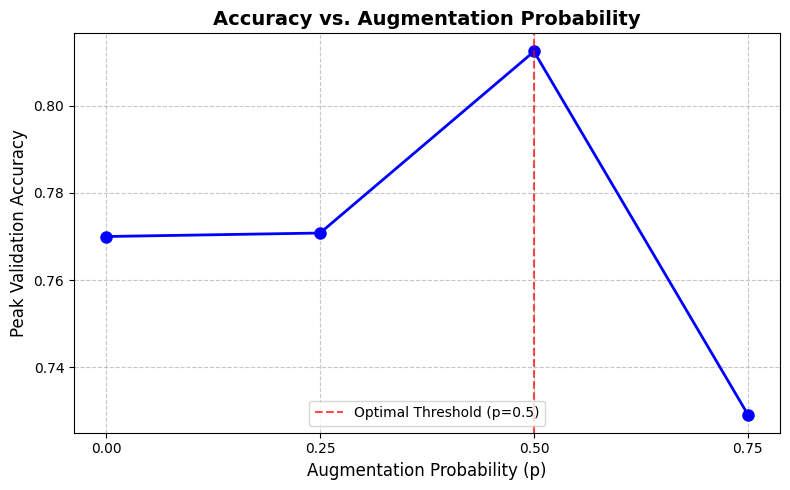

In [ ]:
import matplotlib.pyplot as plt

# The augmentation probabilities yu tested
p_values = [0.0, 0.25, 0.5, 0.75]

# actual peak validation accuracies from the Colab logs
accuracies = [0.77, 0.7708, 0.8125, 0.7291]

plt.figure(figsize=(8, 5))
plt.plot(p_values, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

plt.title('Accuracy vs. Augmentation Probability', fontsize=14, fontweight='bold')
plt.xlabel('Augmentation Probability (p)', fontsize=12)
plt.ylabel('Peak Validation Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(p_values)

plt.axvline(x=0.5, color='r', linestyle='--', alpha=0.7, label='Optimal Threshold (p=0.5)')
plt.legend(loc='lower center')

plt.tight_layout()
plt.show()